## Student Exam Analysis

Let's address the questions about student exam attendance based on the provided data.

In [ ]:
import pandas as pd

# Define the updated DataFrames for Software Engineering
df1SE =  pd.DataFrame({ 'StudentID': [101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121],
                       'ScoreSE' : [65, 78, 45, 82, 91, 58, 73, 60, 88, 77, 95]})
df2SE =  pd.DataFrame({'StudentID': [102, 104, 106, 108, 110, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140],
                       'ScoreSE': [70, 85, 30, 68, 75, 90, 50, 48, 80, 62, 79, 93, 35, 55, 61]})

# Define the updated DataFrames for Machine Learning
df1ML =  pd.DataFrame({ 'StudentID': [100, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 123, 125, 127, 129],
                       'ScoreML' : [72, 80, 55, 90, 63, 76, 49, 81, 70, 50, 85, 92, 40, 66, 71]})
df2ML =  pd.DataFrame({'StudentID': [102, 104, 106, 108, 110, 112, 114, 116, 118, 120],
                       'ScoreML': [88, 38, 70, 95, 60, 82, 42, 53, 91, 74]})

# Concatenate course-specific DataFrames
dfSE = pd.concat([df1SE, df2SE], ignore_index=True).drop_duplicates(subset=['StudentID'])
dfML = pd.concat([df1ML, df2ML], ignore_index=True).drop_duplicates(subset=['StudentID'])

print("Software Engineering Students:")
display(dfSE.head())
print("\nMachine Learning Students:")
display(dfML.head())

Software Engineering Students:


,StudentID,ScoreSE
0,101,65
1,103,78
2,105,45
3,107,82
4,109,91



Machine Learning Students:


,StudentID,ScoreML
0,100,72
1,101,80
2,103,55
3,105,90
4,107,63


In [ ]:
# Get unique StudentIDs for each course
students_se = set(dfSE['StudentID'])
students_ml = set(dfML['StudentID'])

# 1. How many students appeared for the exams in total?
total_students = len(students_se.union(students_ml))
print(f"Total students who appeared for exams: {total_students}")

# 2. How many students only appeared for the Software Engineering course?
only_se_students = len(students_se - students_ml)
print(f"Students who only appeared for Software Engineering exams: {only_se_students}")

# 3. How many students only appeared for the Machine Learning course?
only_ml_students = len(students_ml - students_se)
print(f"Students who only appeared for Machine Learning exams: {only_ml_students}")

Total students who appeared for exams: 36
Students who only appeared for Software Engineering exams: 11
Students who only appeared for Machine Learning exams: 10


In [ ]:
!pip install matplotlib-venn

### Student Overlap: Venn Diagram

This Venn diagram visually represents the number of students taking only Software Engineering, only Machine Learning, and students taking both courses.

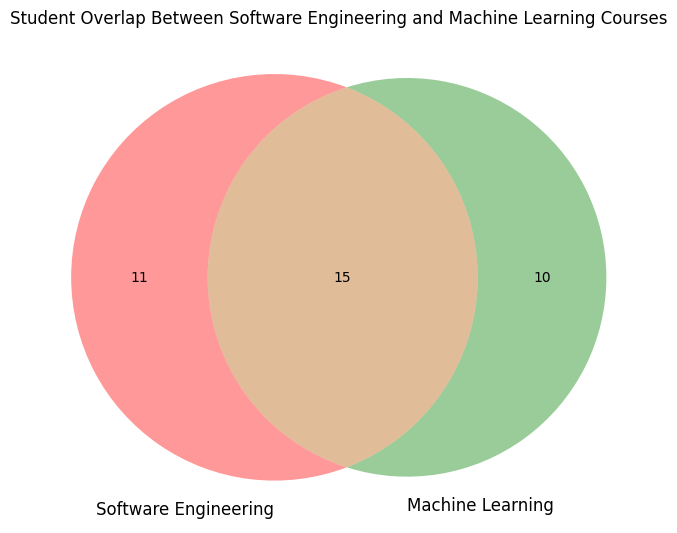

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Assuming students_se and students_ml are already defined from previous cells
# students_se = set(dfSE['StudentID'])
# students_ml = set(dfML['StudentID'])

plt.figure(figsize=(8, 8))
venn2([students_se, students_ml], ('Software Engineering', 'Machine Learning'))
plt.title('Student Overlap Between Software Engineering and Machine Learning Courses')
plt.show()



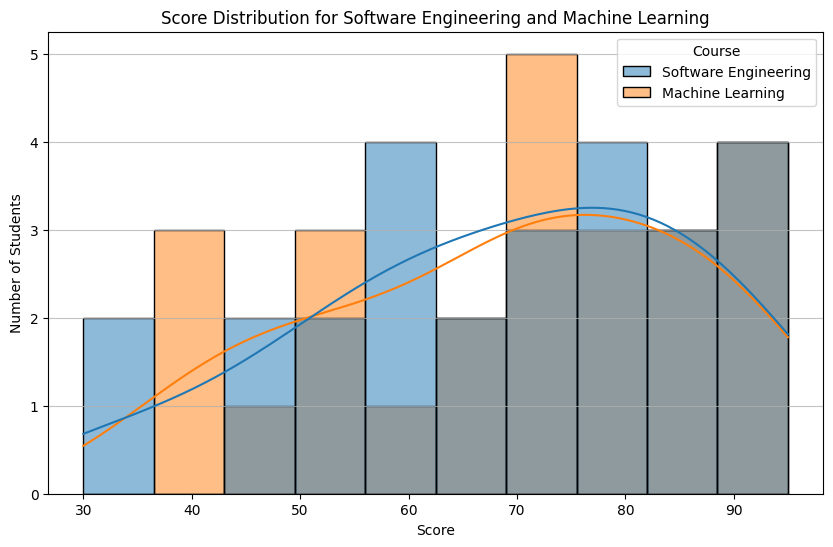

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the updated DataFrames for Software Engineering
df1SE =  pd.DataFrame({ 'StudentID': [101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121],
                       'ScoreSE' : [65, 78, 45, 82, 91, 58, 73, 60, 88, 77, 95]})
df2SE =  pd.DataFrame({'StudentID': [102, 104, 106, 108, 110, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140],
                       'ScoreSE': [70, 85, 30, 68, 75, 90, 50, 48, 80, 62, 79, 93, 35, 55, 61]})

# Define the updated DataFrames for Machine Learning
df1ML =  pd.DataFrame({ 'StudentID': [100, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 123, 125, 127, 129],
                       'ScoreML' : [72, 80, 55, 90, 63, 76, 49, 81, 70, 50, 85, 92, 40, 66, 71]})
df2ML =  pd.DataFrame({'StudentID': [102, 104, 106, 108, 110, 112, 114, 116, 118, 120],
                       'ScoreML': [88, 38, 70, 95, 60, 82, 42, 53, 91, 74]})

# Concatenate course-specific DataFrames
dfSE = pd.concat([df1SE, df2SE], ignore_index=True).drop_duplicates(subset=['StudentID'])
dfML = pd.concat([df1ML, df2ML], ignore_index=True).drop_duplicates(subset=['StudentID'])

# Prepare data for plotting
dfSE['Course'] = 'Software Engineering'
dfML['Course'] = 'Machine Learning'

# Rename score columns for consistent plotting
dfSE_plot = dfSE.rename(columns={'ScoreSE': 'Score'})[['StudentID', 'Score', 'Course']]
dfML_plot = dfML.rename(columns={'ScoreML': 'Score'})[['StudentID', 'Score', 'Course']]

# Combine data for plotting
combined_df = pd.concat([dfSE_plot, dfML_plot], ignore_index=True)

# Plotting the score distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=combined_df, x='Score', hue='Course', kde=True, bins=10)
plt.title('Score Distribution for Software Engineering and Machine Learning')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [4]:
import numpy as np

# Merge dfSE and dfML on StudentID to get all scores for students who took both courses
merged_df = pd.merge(dfSE, dfML, on='StudentID', how='outer')

# Calculate the highest score for each student across both courses
# If a student only took one course, their score for that course will be their highest
merged_df['Highest_Score'] = merged_df[['ScoreSE', 'ScoreML']].max(axis=1)

# Sort by Highest_Score in descending order and get the top 5 students
top_5_students = merged_df.sort_values(by='Highest_Score', ascending=False).head(5)

# Display the top 5 students with their highest scores and course scores
print("Top 5 Students with Highest Scores Across Both Courses:")
display(top_5_students[['StudentID', 'ScoreSE', 'ScoreML', 'Highest_Score']])

Top 5 Students with Highest Scores Across Both Courses:


,StudentID,ScoreSE,ScoreML,Highest_Score
21,121,95.0,NaN,95.0
8,108,68.0,95.0,95.0
32,134,93.0,NaN,93.0
23,123,NaN,92.0,92.0
18,118,NaN,91.0,91.0


In [5]:
# Calculate the average score for Software Engineering
avg_score_se = dfSE['ScoreSE'].mean()
print(f"Average Score for Software Engineering: {avg_score_se:.2f}")

# Calculate the average score for Machine Learning
avg_score_ml = dfML['ScoreML'].mean()
print(f"Average Score for Machine Learning: {avg_score_ml:.2f}")

Average Score for Software Engineering: 68.96
Average Score for Machine Learning: 69.32


/tmp/ipykernel_640/2265012835.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Course', y='Score', palette={'Software Engineering': 'skyblue', 'Machine Learning': 'lightcoral'})


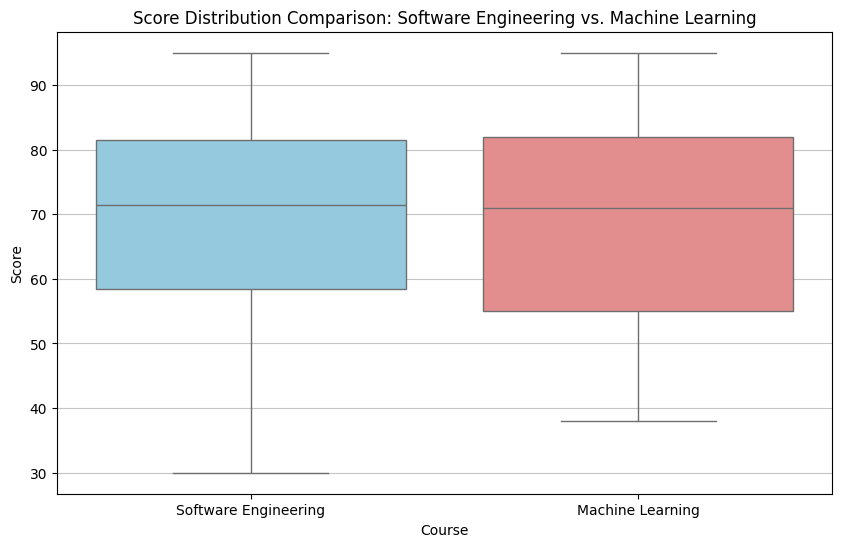

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x='Course', y='Score', palette={'Software Engineering': 'skyblue', 'Machine Learning': 'lightcoral'})
plt.title('Score Distribution Comparison: Software Engineering vs. Machine Learning')
plt.xlabel('Course')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
# Calculate the correlation between Software Engineering and Machine Learning scores
correlation = merged_df['ScoreSE'].corr(merged_df['ScoreML'])

print(f"Correlation between Software Engineering and Machine Learning scores: {correlation:.2f}")

Correlation between Software Engineering and Machine Learning scores: -0.30


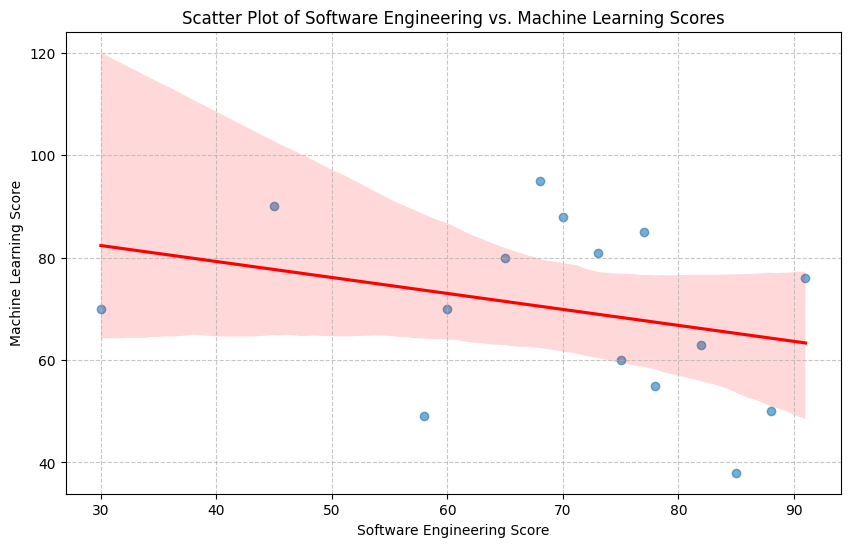

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='ScoreSE', y='ScoreML', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of Software Engineering vs. Machine Learning Scores')
plt.xlabel('Software Engineering Score')
plt.ylabel('Machine Learning Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
# Check for missing values in merged_df
missing_values = merged_df.isnull().sum()

print("Missing values in merged_df:")
display(missing_values)

Missing values in merged_df:


,0
StudentID,0
ScoreSE,10
Course_x,10
ScoreML,11
Course_y,11
Highest_Score,0
